# *LIBRARY*

In [67]:

# IMPORT LIBRARY


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Semua library berhasil di-import")

Semua library berhasil di-import


## LAOD DATA

In [68]:

# LOAD DATA


df = pd.read_csv("data_karyawan.csv")

print("Data berhasil dimuat")
print("\n5 Data Teratas:")
print(df.head())

print("\nInfo Dataset:")
print(df.info())

print("\nStatistik Deskriptif:")
print(df.describe())

Data berhasil dimuat

5 Data Teratas:
   usia  pengalaman_kerja jenis_kelamin pendidikan       gaji
0    56               8.0        Wanita         S2  5058000.0
1    46               7.0        Wanita        SMA  3857000.0
2    32              11.0          Pria        SMA  5358000.0
3    25               1.0          Pria         S2  5561000.0
4    38               0.0        Wanita        SMA  6083000.0

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   usia              100 non-null    int64  
 1   pengalaman_kerja  95 non-null     float64
 2   jenis_kelamin     100 non-null    object 
 3   pendidikan        100 non-null    object 
 4   gaji              100 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 4.0+ KB
None

Statistik Deskriptif:
             usia  pengalaman_kerja          gaji
cou

## DATA CLEAN

In [69]:

# DATA CLEANING

print("Cek Missing Value:")
print(df.isnull().sum())

# Handle missing value pada pengalaman kerja
median_pengalaman = df["pengalaman_kerja"].median()
df["pengalaman_kerja"].fillna(median_pengalaman, inplace=True)

print("\nMissing value setelah cleaning:")
print(df.isnull().sum())

Cek Missing Value:
usia                0
pengalaman_kerja    5
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64

Missing value setelah cleaning:
usia                0
pengalaman_kerja    0
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13160\953222261.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["pengalaman_kerja"].fillna(median_pengalaman, inplace=True)


## ENCODING DATA

In [70]:

# ENCODING DATA


# Encoding gender
df["jenis_kelamin"] = df["jenis_kelamin"].map({
    "Wanita": 0,
    "Pria": 1
})

# Encoding pendidikan (ordinal)
df["pendidikan"] = df["pendidikan"].map({
    "SMA": 0,
    "D3": 1,
    "S1": 2,
    "S2": 3
})

print("Encoding selesai")
print("\nData setelah encoding:")
print(df.head())

Encoding selesai

Data setelah encoding:
   usia  pengalaman_kerja  jenis_kelamin  pendidikan       gaji
0    56               8.0              0           3  5058000.0
1    46               7.0              0           0  3857000.0
2    32              11.0              1           0  5358000.0
3    25               1.0              1           3  5561000.0
4    38               0.0              0           0  6083000.0


## EDA

EXPLORATORY DATA ANALYSIS (EDA)

Statistik Gaji:
count    1.000000e+02
mean     5.039610e+06
std      1.086690e+06
min      1.759000e+06
25%      4.330250e+06
50%      5.067000e+06
75%      5.681500e+06
max      8.853000e+06
Name: gaji, dtype: float64


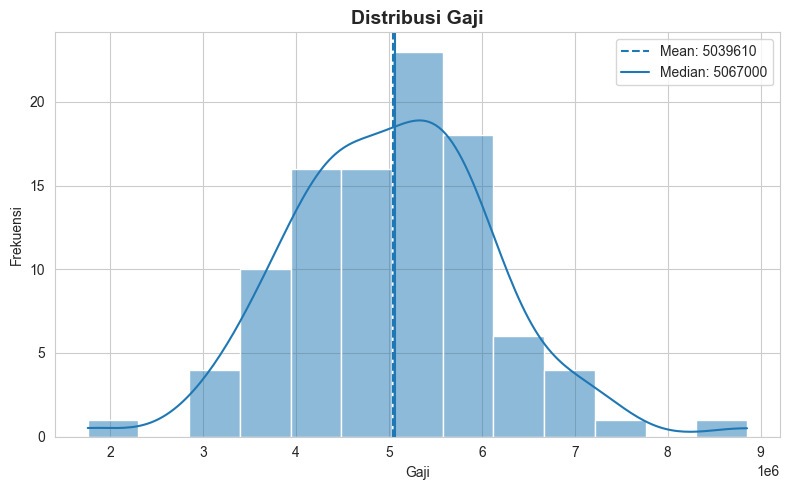

Insight: Distribusi menunjukkan sebaran gaji serta posisi mean dan median.


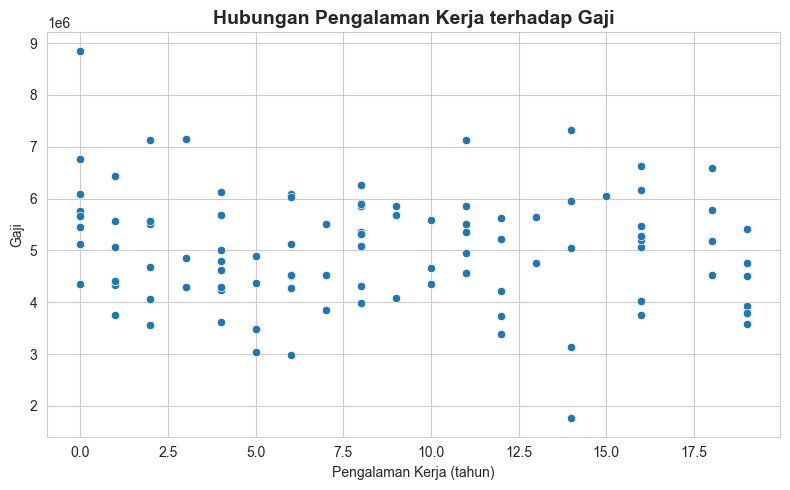

Insight: Terlihat tren hubungan pengalaman kerja dengan peningkatan gaji.


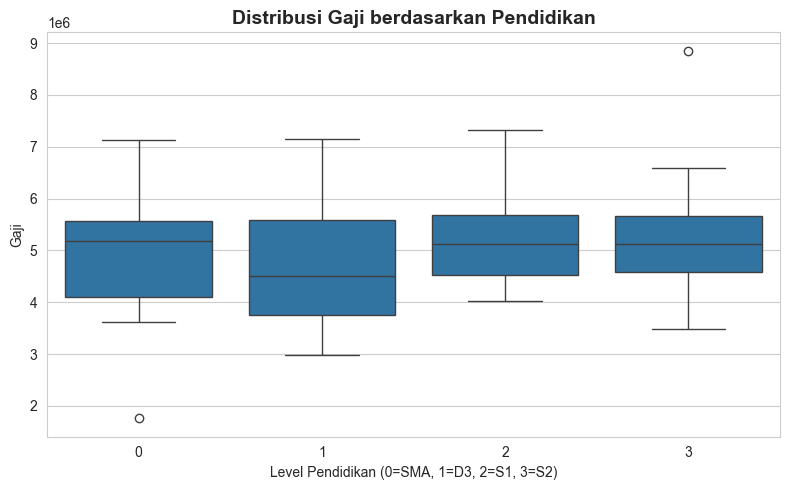

Insight: Perbedaan median dan sebaran gaji antar tingkat pendidikan terlihat jelas.


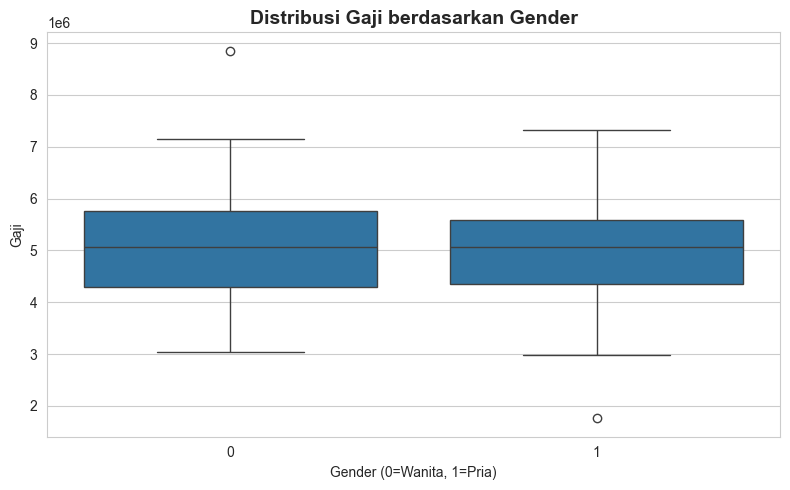

Insight: Perbandingan distribusi gaji antar gender dapat diamati.

EDA selesai dilakukan.


In [71]:

# EXPLORATORY DATA ANALYSIS (PRO)


print("="*50)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

# Ringkasan statistik cepat
print("\nStatistik Gaji:")
print(df["gaji"].describe())

# Set style visual
sns.set_style("whitegrid")


# 1. DISTRIBUSI GAJI

plt.figure(figsize=(8,5))

sns.histplot(df["gaji"], kde=True)

plt.title("Distribusi Gaji", fontsize=14, fontweight='bold')
plt.xlabel("Gaji")
plt.ylabel("Frekuensi")

# garis mean & median
mean_val = df["gaji"].mean()
median_val = df["gaji"].median()

plt.axvline(mean_val, linestyle='--', label=f"Mean: {int(mean_val)}")
plt.axvline(median_val, linestyle='-', label=f"Median: {int(median_val)}")

plt.legend()
plt.tight_layout()
plt.show()

print("Insight: Distribusi menunjukkan sebaran gaji serta posisi mean dan median.")


# 2. PENGALAMAN vs GAJI

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["pengalaman_kerja"],
    y=df["gaji"]
)

plt.title("Hubungan Pengalaman Kerja terhadap Gaji", fontsize=14, fontweight='bold')
plt.xlabel("Pengalaman Kerja (tahun)")
plt.ylabel("Gaji")

plt.tight_layout()
plt.show()

print("Insight: Terlihat tren hubungan pengalaman kerja dengan peningkatan gaji.")


# 3. PENDIDIKAN vs GAJI

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["pendidikan"],
    y=df["gaji"]
)

plt.title("Distribusi Gaji berdasarkan Pendidikan", fontsize=14, fontweight='bold')
plt.xlabel("Level Pendidikan (0=SMA, 1=D3, 2=S1, 3=S2)")
plt.ylabel("Gaji")

plt.tight_layout()
plt.show()

print("Insight: Perbedaan median dan sebaran gaji antar tingkat pendidikan terlihat jelas.")


# 4. GENDER vs GAJI

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["jenis_kelamin"],
    y=df["gaji"]
)

plt.title("Distribusi Gaji berdasarkan Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender (0=Wanita, 1=Pria)")
plt.ylabel("Gaji")

plt.tight_layout()
plt.show()

print("Insight: Perbandingan distribusi gaji antar gender dapat diamati.")


# PENUTUP

print("\nEDA selesai dilakukan.")
print("="*50)

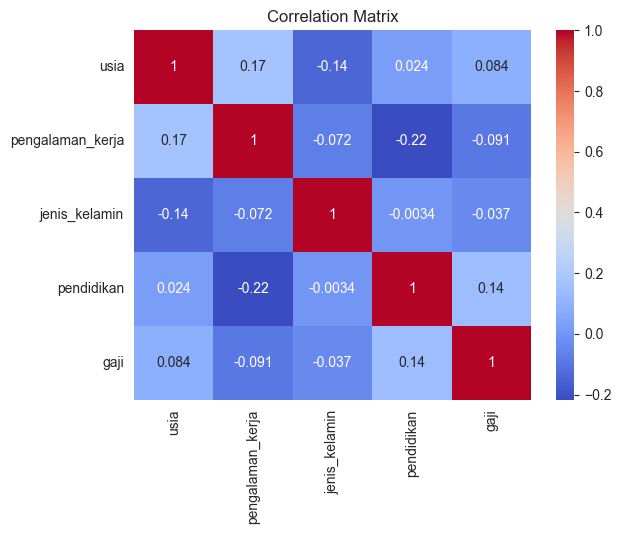

In [72]:
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## FEATURE and TARGET

In [73]:

# FEATURE & TARGET


X = df.drop("gaji", axis=1)
y = df["gaji"]

print("Feature:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature:
   usia  pengalaman_kerja  jenis_kelamin  pendidikan
0    56               8.0              0           3
1    46               7.0              0           0
2    32              11.0              1           0
3    25               1.0              1           3
4    38               0.0              0           0

Target:
0    5058000.0
1    3857000.0
2    5358000.0
3    5561000.0
4    6083000.0
Name: gaji, dtype: float64


# DATA SPLIT

In [74]:
# ================================
# SPLIT DATA
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data berhasil di-split")
print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))

Data berhasil di-split
Jumlah data train: 80
Jumlah data test: 20


## MODEL

In [75]:
# ================================
# MODEL BASELINE
# ================================

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

print("Model Random Forest baseline selesai dilatih")

y_pred = rf.predict(X_test)

print("\nContoh hasil prediksi:")
print(y_pred[:5])

Model Random Forest baseline selesai dilatih

Contoh hasil prediksi:
[5629310. 4846070. 4784240. 4927940. 5228420.]


## EVAL

In [76]:

# EVALUASI MODEL


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== HASIL EVALUASI BASELINE ===")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

=== HASIL EVALUASI BASELINE ===
MAE  : 722503.5
RMSE : 994453.8310776424
R2   : -0.48585902572602824


## FEATURE IMPORTANCE

Ranking Feature Importance:
              Fitur  Importance
0              usia    0.398528
1  pengalaman_kerja    0.384963
3        pendidikan    0.148136
2     jenis_kelamin    0.068373


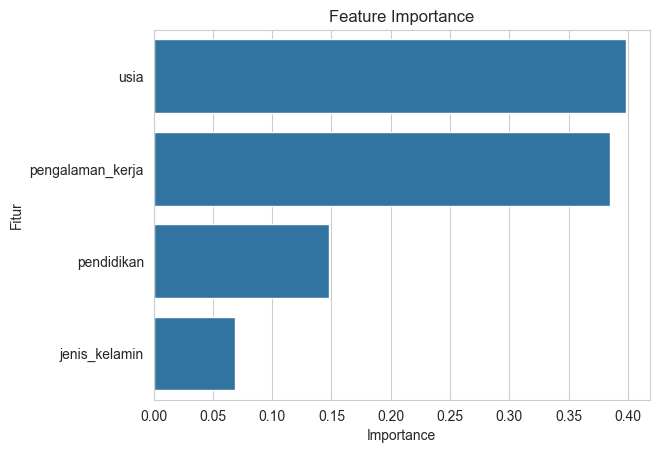

In [77]:

# FEATURE IMPORTANCE


importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Fitur": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Ranking Feature Importance:")
print(importance_df)

plt.figure()
sns.barplot(x="Importance", y="Fitur", data=importance_df)
plt.title("Feature Importance")
plt.show()

## TUNNIG

In [78]:

# HYPERPARAMETER TUNING


param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Tuning selesai")
print("Best Parameters:", grid.best_params_)

Tuning selesai
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


## BEST MODEL

In [79]:

# MODEL TERBAIK


best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("=== HASIL MODEL TUNED ===")
print("MAE  :", mae_best)
print("RMSE :", rmse_best)
print("R2   :", r2_best)

=== HASIL MODEL TUNED ===
MAE  : 641981.3570436507
RMSE : 930569.5003159494
R2   : -0.30108594348326156


## PERBANDINGAN

In [80]:

# PERBANDINGAN MODEL


comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "MAE": [mae, mae_best],
    "RMSE": [rmse, rmse_best],
    "R2": [r2, r2_best]
})

print("Perbandingan Model:")
print(comparison)

Perbandingan Model:
      Model            MAE           RMSE        R2
0  Baseline  722503.500000  994453.831078 -0.485859
1     Tuned  641981.357044  930569.500316 -0.301086


In [81]:
print("HITUNG METRIK PER MODEL")

# Baseline
mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

# Tuned
mae_tuned = mean_absolute_error(y_test, y_pred_best)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_tuned = r2_score(y_test, y_pred_best)

print("\nBaseline:")
print("MAE  :", mae_base)
print("RMSE :", rmse_base)
print("R2   :", r2_base)

print("\nTuned:")
print("MAE  :", mae_tuned)
print("RMSE :", rmse_tuned)
print("R2   :", r2_tuned)

HITUNG METRIK PER MODEL

Baseline:
MAE  : 722503.5
RMSE : 994453.8310776424
R2   : -0.48585902572602824

Tuned:
MAE  : 641981.3570436507
RMSE : 930569.5003159494
R2   : -0.30108594348326156


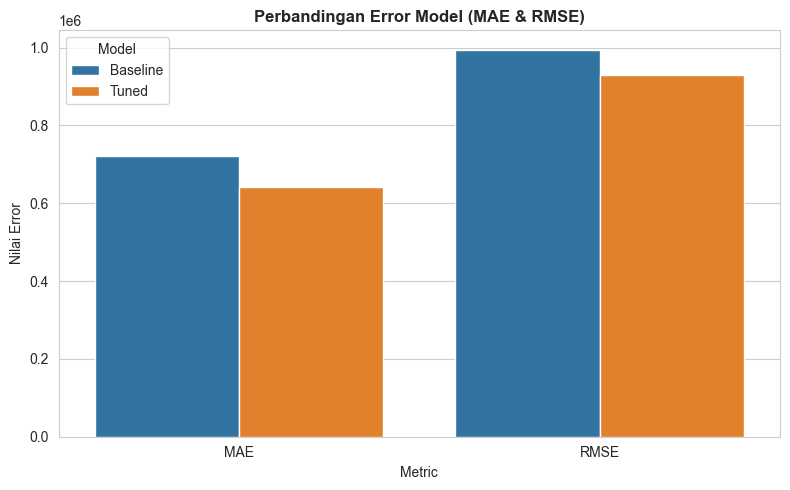

In [82]:
plt.figure(figsize=(8,5))

comparison_melt = comparison.melt(id_vars="Model", value_vars=["MAE","RMSE"])

sns.barplot(
    x="variable",
    y="value",
    hue="Model",
    data=comparison_melt
)

plt.title("Perbandingan Error Model (MAE & RMSE)", fontweight='bold')
plt.xlabel("Metric")
plt.ylabel("Nilai Error")

plt.tight_layout()
plt.show()

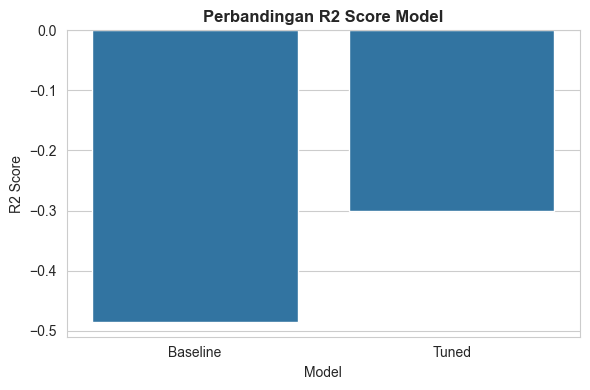

In [83]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Model",
    y="R2",
    data=comparison
)

plt.title("Perbandingan R2 Score Model", fontweight='bold')
plt.ylabel("R2 Score")

plt.tight_layout()
plt.show()

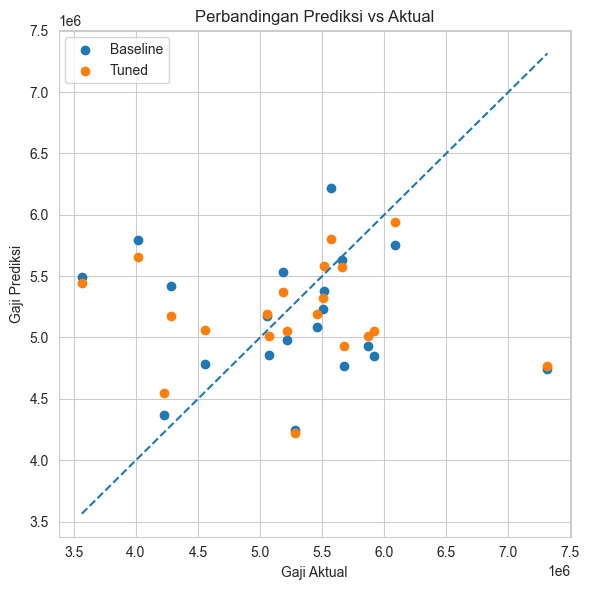

In [84]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, label="Baseline")
plt.scatter(y_test, y_pred_best, label="Tuned")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Gaji Aktual")
plt.ylabel("Gaji Prediksi")
plt.title("Perbandingan Prediksi vs Aktual")

plt.legend()
plt.tight_layout()
plt.show()

## DATA BARU

In [85]:

# PREDIKSI DATA BARU


data_baru = pd.DataFrame({
    "usia": [30],
    "pengalaman_kerja": [5],
    "jenis_kelamin": [1],
    "pendidikan": [2]
})

hasil = best_model.predict(data_baru)

print("Data baru:")
print(data_baru)

print("\nPrediksi Gaji:")
print(int(hasil[0]))

Data baru:
   usia  pengalaman_kerja  jenis_kelamin  pendidikan
0    30                 5              1           2

Prediksi Gaji:
4534279


#  Bagaimana cara menentukan gaji yang adil dan kompetitif untuk calon karyawan baru?

Gunakan model terbaik (tuned Random Forest) sebagai alat prediksi.

Mekanisme:
Input kandidat model menghasilkan prediksi gaji
Gunakan MAE sebagai margin error
Formula:
batas bawah = prediksi − MAE
batas atas = prediksi + MAE

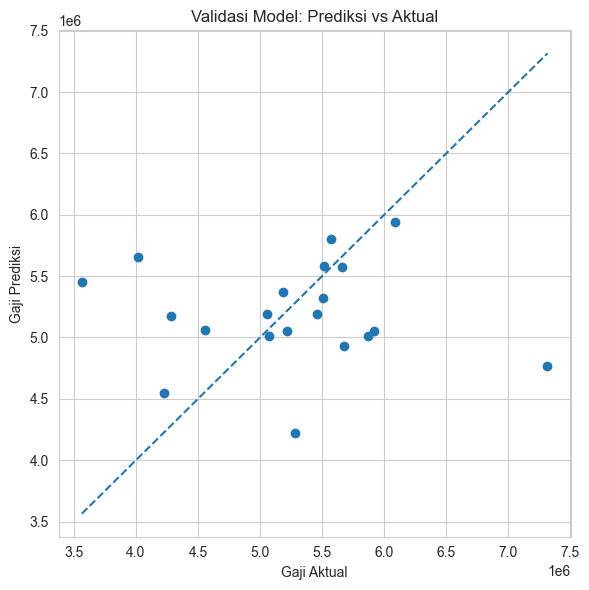

In [86]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Gaji Aktual")
plt.ylabel("Gaji Prediksi",)
plt.title("Validasi Model: Prediksi vs Aktual")

plt.tight_layout()
plt.show()

# Visualisasi Range Gaji 

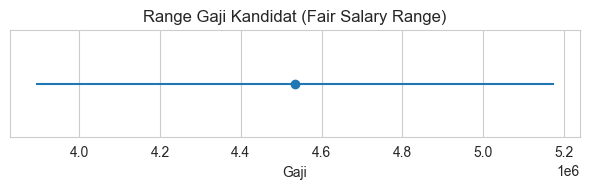

Prediksi: 4534279
Range: 3892297 - 5176260


In [87]:
# contoh kandidat
data_baru = pd.DataFrame({
    "usia": [30],
    "pengalaman_kerja": [5],
    "jenis_kelamin": [1],
    "pendidikan": [2]
})

prediksi = best_model.predict(data_baru)[0]

lower = prediksi - mae_best
upper = prediksi + mae_best

plt.figure(figsize=(6,2))

plt.hlines(1, lower, upper)
plt.plot(prediksi, 1, 'o')

plt.title("Range Gaji Kandidat (Fair Salary Range)")
plt.xlabel("Gaji")
plt.yticks([])

plt.tight_layout()
plt.show()

print("Prediksi:", int(prediksi))
print("Range:", int(lower), "-", int(upper))

# Faktor yang mempengaruhi gaji

              Fitur     Nilai
1  pengalaman_kerja  0.437957
0              usia  0.347526
3        pendidikan  0.155639
2     jenis_kelamin  0.058878


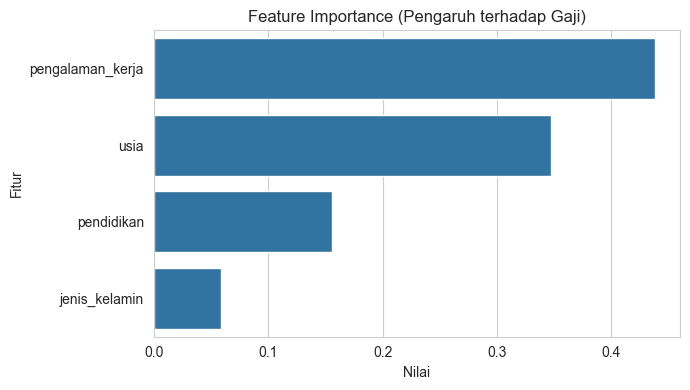

In [88]:
importance = pd.DataFrame({
    "Fitur": X.columns,
    "Nilai": best_model.feature_importances_
}).sort_values(by="Nilai", ascending=False)

print(importance)

plt.figure(figsize=(7,4))
sns.barplot(x="Nilai", y="Fitur", data=importance)

plt.title("Feature Importance (Pengaruh terhadap Gaji)")
plt.tight_layout()
plt.show()

##  *Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing. (20 Point, CLOP-4)*

Peran feature engineering adalah mengubah data mentah agar model bisa belajar hubungan antara variabel dengan lebih akurat.

Pada studi kasus Mirna:
Data awal hanya berisi usia, pengalaman kerja, jenis kelamin, dan tingkat pendidikan. Data ini belum sepenuhnya siap digunakan.

Proses feature engineering:
Jenis kelamin diubah menjadi numerik menggunakan encoding
Tingkat pendidikan diubah menjadi numerik atau one hot
Membuat fitur baru seperti rasio pengalaman terhadap usia untuk melihat percepatan karier
Mengelompokkan pengalaman menjadi level seperti junior, mid, senior




##  *Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing. (20 Point, CLOP-4)*
Confusion matrix adalah alat evaluasi untuk model klasifikasi yang membandingkan hasil prediksi dengan kondisi sebenarnya.


Komponen:
True Positive adalah prediksi benar untuk kelas positif
False Positive adalah prediksi positif tapi sebenarnya salah
True Negative adalah prediksi benar untuk kelas negatif
False Negative adalah prediksi negatif tapi sebenarnya salah

Contoh pada studi kasus Mirna jika diubah jadi klasifikasi:
Misalnya gaji dibagi dua kategori
Gaji tinggi di atas 10 juta
Gaji rendah di bawah atau sama dengan 10 juta